# 04 — Model layer

Notebook 03 produced **`PreprocessedDataset`** — a clean `(X, y)` ready to train on. This notebook builds the **model layer**: a typed `BaseRegressor` ABC, a `ModelFactory`, and three concrete models that exercise the abstraction's extremes.

## Architecture

```text
BaseRegressor[P]              ABC, generic over typed params
    fit(X, y) -> Self
    predict(X) -> pd.Series   index aligned to X.index
    params: P                 typed, frozen, JSON-serialisable
    save(dir) / load(dir)     dispatched via ModelKind on disk

BaseModelParams               ABC, frozen
    kind: ModelKind           drives factory + persistence dispatch

ModelKind (StrEnum)
    .params_type()            kind → params dataclass
    .model_class()            kind → BaseRegressor subclass
```

## What each concrete model exercises

| Model | Why it's here |
|---|---|
| `MeanBaselineRegressor` | Sanity baseline. Anything worse than this in NB 06 has a bug. No scaling, no hyperparameters worth tuning — exercises the contract at its simplest. |
| `RandomForestRegressor` | Realistic baseline. Tree-based → no scaling needed. Exercises the abstraction with a non-trivial fitted state (`joblib`-pickled forest). |
| `LinearRegressor` | Exercises the **in-wrapper scaling contract**. Fits a `StandardScaler` on the training fold + an OLS regression. Future NN wrappers will use the same pattern. |

The architectural decision (carried over from NB 03):

> **Scaling lives in the model wrapper, not the Preprocessor.** RF doesn't need it; Linear does. Each wrapper owns its own scaler so cross-fold leakage is impossible by construction — the `Preprocessor` stays stateless, and the train fold is the *only* data that reaches `.fit(...)`.


## 0 — Setup


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from datetime import date
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

src_path = (Path.cwd() / "../src").resolve()
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print("Python", sys.version.split()[0])


Python 3.12.1


## 1 — Load the preprocessed dataset from NB 03

This loads the canonical v1 snapshot (built by NB 02), applies the v1 `FeatureSpec` (defined inline below — same as NB 03), and produces a `PreprocessedDataset` with `X()` and `y()` slices ready for training.


In [2]:
from susse.datasets import load_snapshot
from susse.preprocessing import (
    ClearSkyIndexSpec, FeatureSpec, Preprocessor,
)

SNAPSHOT_DIR = (Path.cwd() / "../data/training_snapshots/susse_training_demo_v1-2024H1").resolve()
dataset = load_snapshot(SNAPSHOT_DIR)
print(f"Loaded {dataset.manifest.name} {dataset.manifest.version}: "
      f"{dataset.manifest.n_rows} rows × {dataset.manifest.n_cols} cols")

spec = FeatureSpec(
    target_column="y_ghi_kwh_m2_day",
    feature_columns=(
        "nasa_aod_550",
        "nasa_precipitable_water",
        "nasa_cloud_amount",
        "nasa_clearness_index",
        "sat_ghi_nasa_kwh_m2_day",
        "sat_ghi_cams_kwh_m2_day",
    ),
    clear_sky_index_specs=(
        ClearSkyIndexSpec(
            ghi_column="sat_ghi_cams_kwh_m2_day",
            ghi_clear_column="cams_ghi_clear",
            output_column="kt_cams",
        ),
    ),
    include_cyclical_doy=True,
)

processed = Preprocessor(spec).apply(dataset)
print(f"Processed: {processed.n_rows} rows × {processed.n_features} features")
print(f"Feature columns: {processed.feature_columns}")


Loaded susse_training_demo v1-2024H1: 3710 rows × 14 cols
Processed: 3710 rows × 9 features
Feature columns: ('nasa_aod_550', 'nasa_precipitable_water', 'nasa_cloud_amount', 'nasa_clearness_index', 'sat_ghi_nasa_kwh_m2_day', 'sat_ghi_cams_kwh_m2_day', 'kt_cams', 'doy_sin', 'doy_cos')


## 2 — Train/test holdout

Proper splitting (random / temporal / station-LOSO / spatial-block) is decided in NB 06. For NB 04's purposes — exercising the model abstraction — a simple deterministic random split is enough. The 80/20 fraction and seed are pinned here so the model comparison numbers below stay reproducible.


In [3]:
RANDOM_SEED = 42
TRAIN_FRACTION = 0.8

shuffled_idx = (
    processed.df.sample(frac=1.0, random_state=RANDOM_SEED).index
)
n_train = int(TRAIN_FRACTION * len(shuffled_idx))
train_idx = shuffled_idx[:n_train]
test_idx = shuffled_idx[n_train:]

X_train = processed.X().loc[train_idx]
y_train = processed.y().loc[train_idx]
X_test = processed.X().loc[test_idx]
y_test = processed.y().loc[test_idx]

print(f"Train: {len(X_train):,} rows | Test: {len(X_test):,} rows")
print(f"y_train mean = {y_train.mean():.3f} kWh/m²/day "
      f"(std = {y_train.std():.3f})")


Train: 2,968 rows | Test: 742 rows
y_train mean = 5.360 kWh/m²/day (std = 1.447)


## 3 — Train all three models via `ModelFactory`

Each call follows the same shape: `params → ModelFactory.create(params) → .fit(X, y)`. The typed params dataclass is the only API surface; no `model_type="random_forest"` strings, no `dict(params)` to misspell.


In [4]:
from susse.models import (
    LinearParams, MeanBaselineParams, ModelFactory, RandomForestParams,
)

mean_model = ModelFactory.create(MeanBaselineParams()).fit(X_train, y_train)
rf_model = ModelFactory.create(
    RandomForestParams(n_estimators=200, max_depth=12, random_state=42)
).fit(X_train, y_train)
linear_model = ModelFactory.create(
    LinearParams(with_scaling=True)
).fit(X_train, y_train)

print(f"Trained: {type(mean_model).__name__}, "
      f"{type(rf_model).__name__}, "
      f"{type(linear_model).__name__}")


Trained: MeanBaselineRegressor, RandomForestRegressor, LinearRegressor


## 4 — Compare on the held-out test set

NB 06 will ship the proper metrics class (and the splitter that decides what "test" actually means). For now: MAE, RMSE, and naive R² are enough to confirm the abstraction works and the models behave as expected (RF ≪ Linear ≪ Mean baseline on training-distribution-aligned holdout).


In [5]:
def _score(y_true, y_pred):
    err = y_pred - y_true
    mae = err.abs().mean()
    rmse = np.sqrt((err ** 2).mean())
    ss_res = (err ** 2).sum()
    ss_tot = ((y_true - y_true.mean()) ** 2).sum()
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")
    return mae, rmse, r2


rows = []
for name, model in [
    ("MeanBaseline", mean_model),
    ("RandomForest", rf_model),
    ("Linear", linear_model),
]:
    mae, rmse, r2 = _score(y_test, model.predict(X_test))
    rows.append({"model": name, "mae": mae, "rmse": rmse, "r2": r2})

scores = pd.DataFrame(rows).set_index("model")
scores


,mae,rmse,r2
model,,,
MeanBaseline,1.154990,1.432074,-0.000142
RandomForest,0.485622,0.777813,0.704960
Linear,0.525273,0.792170,0.693968


A scatter of predictions vs ground truth, one panel per model. The diagonal is `y_pred = y_true`; tighter clouds around the diagonal mean lower error.


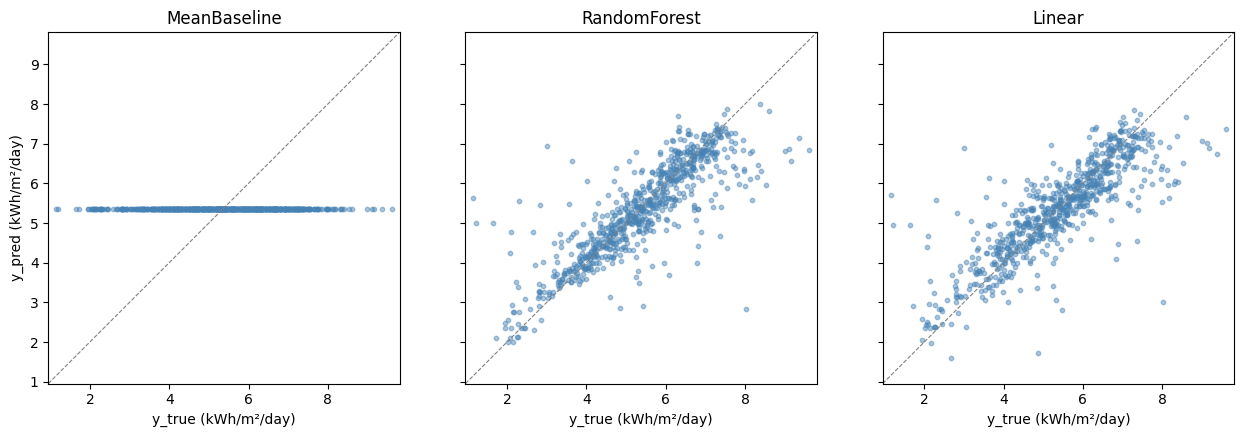

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True, sharex=True)

for ax, (name, model) in zip(
    axes,
    [("MeanBaseline", mean_model), ("RandomForest", rf_model), ("Linear", linear_model)],
):
    preds = model.predict(X_test)
    ax.scatter(y_test, preds, s=10, alpha=0.45, color="steelblue")
    lim = (
        min(y_test.min(), preds.min()) - 0.2,
        max(y_test.max(), preds.max()) + 0.2,
    )
    ax.plot(lim, lim, "--", color="gray", linewidth=0.8)
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_xlabel("y_true (kWh/m²/day)")
    ax.set_aspect("equal")
    ax.set_title(name)

axes[0].set_ylabel("y_pred (kWh/m²/day)")
plt.tight_layout()


## 5 — Save / load roundtrip

Each model persists into a directory holding `model_kind.txt`, `params.json`, and `state.joblib`. The package-level `load_regressor(dir)` reads the kind tag and dispatches to the right concrete class — no caller-side knowledge of which model was trained.


In [7]:
from susse.models import load_regressor

MODELS_ROOT = (Path.cwd() / "../data/models").resolve()
MODELS_ROOT.mkdir(parents=True, exist_ok=True)

for name, model in [
    ("mean_baseline", mean_model),
    ("random_forest", rf_model),
    ("linear", linear_model),
]:
    out = MODELS_ROOT / f"_nb04_{name}"
    model.save(out)
    restored = load_regressor(out)
    # Tolerance accommodates ~1-ulp drift from joblib pickling/unpickling
    # of linear coefficients — well below any meaningful prediction change.
    np.testing.assert_allclose(
        restored.predict(X_test).values, model.predict(X_test).values,
        rtol=1e-10, atol=1e-10,
    )
    print(f"{name}: roundtrip OK — restored as {type(restored).__name__}")


mean_baseline: roundtrip OK — restored as MeanBaselineRegressor
random_forest: roundtrip OK — restored as RandomForestRegressor
linear: roundtrip OK — restored as LinearRegressor


The persistence format is stable and human-readable — `cat model_kind.txt` and `cat params.json` are sensible operations. State (the fitted forest, the scaler + linear coefficients) lives in a single joblib blob.


In [8]:
example_dir = MODELS_ROOT / "_nb04_random_forest"
print("Files in", example_dir.name, ":")
for f in sorted(example_dir.iterdir()):
    print(f"  {f.name}  ({f.stat().st_size:,} bytes)")
print()
print("model_kind.txt :", (example_dir / "model_kind.txt").read_text())
print("params.json    :")
print((example_dir / "params.json").read_text())


Files in _nb04_random_forest :
  model_kind.txt  (13 bytes)
  params.json  (186 bytes)
  state.joblib  (21,622,993 bytes)

model_kind.txt : random_forest
params.json    :
{
  "kind": "random_forest",
  "max_depth": 12,
  "max_features": "sqrt",
  "min_samples_leaf": 1,
  "min_samples_split": 2,
  "n_estimators": 200,
  "n_jobs": -1,
  "random_state": 42
}


## What's next

* **NB 05 — `05_training.ipynb`** — the `Trainer` that orchestrates `ModelFactory.create → fit → predict → score → wandb.log_artifact`, plus the `TrainedBundle` value object that pairs a fitted model with the `FeatureSpec` it consumes (so inference reconstructs identical transforms from a single artifact).
* **NB 06** — proper validation splitters (random / temporal / station-LOSO / spatial-block) and the metrics class.

The discipline going forward, mirroring NB 02 / 03:

| Change | What ripples |
|---|---|
| New hyperparameters on RF | New `RandomForestParams` instance → train → bump model artifact version |
| Add a fourth model class (e.g. XGBoost) | New `ModelKind` member + params dataclass + concrete subclass + entries in `ModelKind.params_type()` / `model_class()`. Three lines per file. |
| Switch a model from no-scaling to scaling | New params field; the wrapper's `fit/predict/save/load` already accommodates the change |

The model layer is single-responsibility: it consumes `(X, y)` and produces predictions. It deliberately knows nothing about W&B, MLflow, or the warehouse. Wiring those concerns belongs to the trainer (NB 05).
